In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

_here = Path(os.path.abspath(""))
while not (_here / "pixi.toml").exists():
    _here = _here.parent
    if _here == _here.parent:
        raise RuntimeError("Could not find repo root")
os.chdir(_here)

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from src.experiments_analysis.sensitivity_analysis_pipeline import (
    make_config,
    run_sensitivity_analysis_multi_seed,
    build_metrics_df,
    sensitivity_barplot,
    print_chosen_alphas,
)

BASELINES_PATH = "experiments/benchmark_output_files/sensitivity_analysis/simulation_baselines.yaml"
RUNS_PATH = "experiments/benchmark_output_files/sensitivity_analysis/simulation_merge.yaml"
cfg = make_config(BASELINES_PATH, RUNS_PATH)
output_dir = cfg["output_dir"]
figures_output_dir = Path(cfg["figures_output_dir"])
figures_output_dir.mkdir(exist_ok=True, parents=True)
Path(output_dir).mkdir(parents=True, exist_ok=True)

auto.py (21): IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


## Run analysis pipeline

In [4]:
run_sensitivity_analysis_multi_seed(cfg, synthetic_data=True)

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/destriping/GLUM/get_metrics_dist.py:17: UserWarning: computing sol metrics for seed_42__p_merge_0.01: Metrics: 4 missing indices in h. Filling with ones.
  warnings.warn(
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/destriping/GLUM/get_metrics_dist.py:17: UserWarning: computing sol metrics for seed_42__p_merge_0.01: Metrics: 3 missing indices in w. Filling with ones.
  warnings.warn(
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/destriping/GLUM/get_metrics_dist.py:17: UserWarning: computing sol metrics for seed_42__p_merge_10: Metrics: 4 missing indices in h. Filling with ones.
  warnings.warn(
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/destriping/GLUM/get_metrics_dist.py:17: UserWarning: computing sol metrics for seed_42__p_merge_10: Metrics: 3 missing indices in w. Filling with ones.
  warnings.warn(
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/

,name,distance_to_gt_poisson_sol_hw_log_euclidian,converged
24,GT_poisson_sol,0.000000,NaN
7,seed_64__p_merge_10,0.114171,True
1,seed_42__p_merge_10,0.125284,True
0,seed_42__p_merge_0.01,0.162324,True
9,seed_64__p_merge_50,0.164854,True
18,ours,0.167126,True
12,seed_754__p_merge_0.01,0.167647,True
3,seed_42__p_merge_50,0.173502,True
15,seed_754__p_merge_50,0.173534,True
13,seed_754__p_merge_10,0.174349,True


/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis.py:279: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  destriped_summary_df.groupby("name").apply(select_method).reset_index(drop=True)


2SN 0
GT_nbinom_sol 1
GT_poisson_sol 2
b2c-sym-c_mean 3
collapse_label 4
dividing_99_quantile 5
expected_spatial_data_wo_stripes 6
original 7
ours 8
seed_42__p_merge_0.01 9
seed_42__p_merge_10 10
seed_42__p_merge_100 11
seed_42__p_merge_25 12
seed_42__p_merge_50 13
seed_42__p_merge_80 14
seed_64__p_merge_0.01 15
seed_64__p_merge_10 16
seed_64__p_merge_100 17
seed_64__p_merge_25 18
seed_64__p_merge_50 19
seed_64__p_merge_80 20
seed_754__p_merge_0.01 21
seed_754__p_merge_10 22
seed_754__p_merge_100 23
seed_754__p_merge_25 24
seed_754__p_merge_50 25
seed_754__p_merge_80 26


## Results table + barplot

In [13]:
output_dir

'results/segmentation_sensitivity/simulation_4_with_struct_nb_weibul_2_seed_546/analysis_merge'

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis_plots.py:873: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/sensitivity_analysis_pipeline.py:883: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  


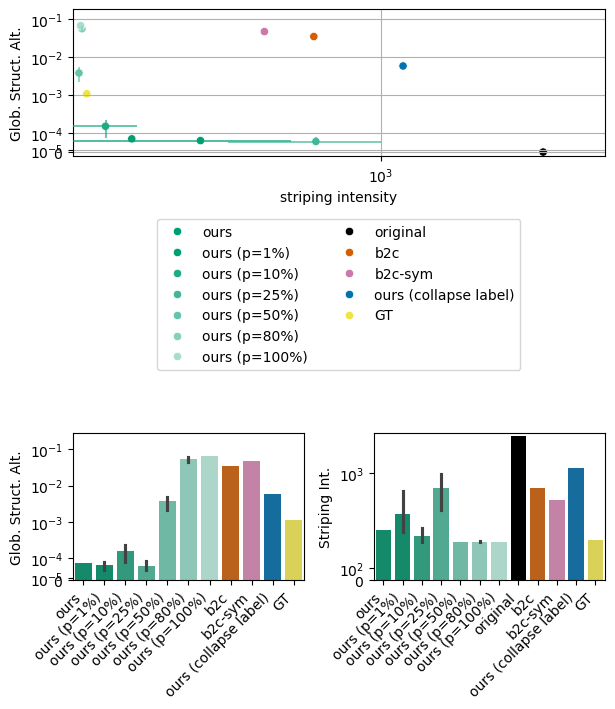

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis.py:279: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  destriped_summary_df.groupby("name").apply(select_method).reset_index(drop=True)
/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis_plots.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selection["name"] = df_selection["name"].cat.remove_unused_categories()
/Users/pm

                                name  \
0                        ours (p=1%)   
1                        ours (p=1%)   
2                        ours (p=1%)   
3                       ours (p=10%)   
4                       ours (p=10%)   
..                               ...   
56                    b2c-sym-c_mean   
57                          original   
58                           b2c-sym   
59                               b2c   
60  expected_spatial_data_wo_stripes   

    Log-space L2 error in $(\mathbf{h}, \mathbf{w})$  \
0                                           0.162324   
1                                           0.162324   
2                                           0.162324   
3                                           0.125284   
4                                           0.125284   
..                                               ...   
56                                          8.930994   
57                                          0.478410   
58             

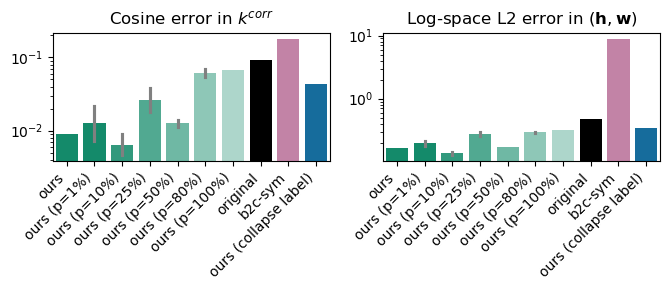

In [12]:
from src.experiments_analysis.sensitivity_analysis_pipeline import simulation_data_plots

simulation_data_plots(output_dir, figures_output_dir, "merge")

## Chosen alpha per model

In [15]:
print_chosen_alphas(RUNS_PATH)

Chosen alpha:
seed             42        64        754
run                                     
p_merge_1   0.000046  0.001000  0.000215
p_merge_10  0.001000  0.001000  0.001000
p_merge_25  0.001000  0.000215  0.001000
p_merge_50  0.000215  0.004642  0.001000

Boundary hit wrt full CV grid (MIN / MAX / ok):
seed       42  64  754
run                   
p_merge_1   ok  ok  ok
p_merge_10  ok  ok  ok
p_merge_25  ok  ok  ok
p_merge_50  ok  ok  ok


,run,seed,alpha,grid_min,grid_max,boundary_side
0,p_merge_1,42,0.000046,0.00001,10.0,ok
1,p_merge_10,42,0.001000,0.00001,10.0,ok
2,p_merge_25,42,0.001000,0.00001,10.0,ok
3,p_merge_50,42,0.000215,0.00001,10.0,ok
4,p_merge_1,64,0.001000,0.00001,10.0,ok
5,p_merge_10,64,0.001000,0.00001,10.0,ok
6,p_merge_25,64,0.000215,0.00001,10.0,ok
7,p_merge_50,64,0.004642,0.00001,10.0,ok
8,p_merge_1,754,0.000215,0.00001,10.0,ok
9,p_merge_10,754,0.001000,0.00001,10.0,ok


## Visualization of the cell-size for seed 42

<Figure size 700.9x560.72 with 0 Axes>

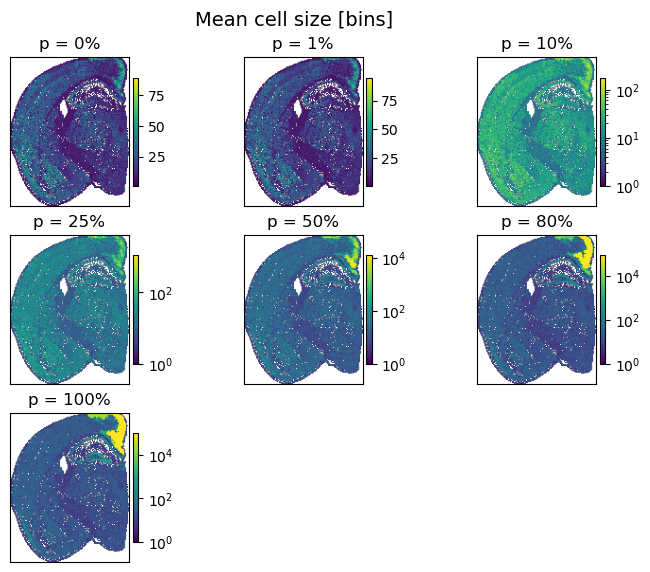

In [8]:
from src.experiments_analysis.sensitivity_analysis_pipeline import load_cell_size_inputs
from src.experiments_analysis.plots_cell_size import plot_mean_cell_size

cfg_42 = {**cfg, "runs": cfg["seeds"][42]["runs"]}
labels_by_p, coords, stats_df = load_cell_size_inputs(cfg_42)
plot_mean_cell_size(labels_by_p, coords, stats_df, bin_size=20)
plt.savefig(figures_output_dir/ "avg_cell_size.pdf")
plt.show()

In [ ]:
(labels_by_p[0.01] == labels_by_p[0.5]).all()

True

<string>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


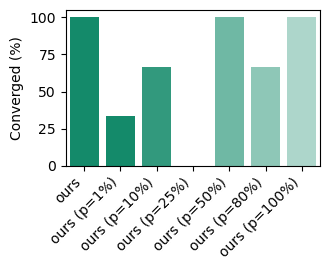

In [14]:
from src.experiments_analysis.sensitivity_analysis_pipeline import convergence_barplot

ax = convergence_barplot(output_dir, experiment_type="merge")
plt.show()